In [124]:
#!/usr/bin/env python3
"""Inspect a ROOT file and print object contents plus useful drawing options."""

from __future__ import annotations
import argparse
from pathlib import Path
from typing import Iterable

try:
    import ROOT
except Exception as exc:
    raise SystemExit(
        "PyROOT import failed. Make sure your environment has ROOT installed.\n"
        f"{exc}"
    )


COMMON_DRAW_OPTIONS = {
    "TH1": [
        "HIST",
        "E",
        "E1",
        "E SAME",
        "P",
        "L",
        "BAR",
        "TEXT",
    ],
    "TH2": [
        "COL",
        "COLZ",
        "COLZ0",
        "TEXT",
        "TEXT SAME",
        "BOX",
        "BOX SAME",
        "CONT",
        "CONT1",
        "CONT4",
        "LEGO",
        "LEGO2",
        "SURF",
        "SURF1",
        "ARR",
        "SCAT",
    ],
    "TH3": [
        "BOX",
        "ISO",
        "LEGO",
        "GLBOX",
        "GLISO",
    ],
    "TGraph": [
        "AP",
        "AL",
        "APL",
        "P",
        "L",
        "C",
        "AC",
    ],
}


PALETTE_HINTS = [
    "kBird",
    "kRainBow",
    "kViridis",
    "kGreyScale",
    "kDeepSea",
    "kDarkBodyRadiator",
    "kBlueYellow",
    "kCividis",
]


def iter_keys(directory: ROOT.TDirectory) -> Iterable[ROOT.TKey]:
    keys = directory.GetListOfKeys()
    if not keys:
        return []
    return [keys.At(index) for index in range(keys.GetSize())]


def fmt(value: float) -> str:
    return f"{value:.6g}"


def describe_axis(axis: ROOT.TAxis, name: str) -> str:
    if not axis:
        return f"{name}: <missing>"
    return (
        f"{name}: bins={axis.GetNbins()}, min={fmt(axis.GetXmin())}, "
        f"max={fmt(axis.GetXmax())}, title='{axis.GetTitle()}'"
    )


def describe_histogram(obj, indent: str) -> None:
    print(f"{indent}entries={fmt(obj.GetEntries())}")
    print(f"{indent}minimum={fmt(obj.GetMinimum())}, maximum={fmt(obj.GetMaximum())}")

    if obj.InheritsFrom("TH2") or obj.InheritsFrom("TProfile2D"):
        stored_min = obj.GetMinimumStored()
        stored_max = obj.GetMaximumStored()
        print(
            f"{indent}stored z-range override="
            f"({fmt(stored_min)}, {fmt(stored_max)})"
        )

    print(f"{indent}{describe_axis(obj.GetXaxis(), 'x-axis')}")
    print(f"{indent}{describe_axis(obj.GetYaxis(), 'y-axis')}")

    get_zaxis = getattr(obj, "GetZaxis", None)
    if callable(get_zaxis):
        print(f"{indent}{describe_axis(get_zaxis(), 'z-axis')}")


def class_draw_options(obj) -> list[str]:
    if obj.InheritsFrom("TH3"):
        return COMMON_DRAW_OPTIONS["TH3"]
    if obj.InheritsFrom("TH2") or obj.InheritsFrom("TProfile2D"):
        return COMMON_DRAW_OPTIONS["TH2"]
    if obj.InheritsFrom("TH1") or obj.InheritsFrom("TProfile"):
        return COMMON_DRAW_OPTIONS["TH1"]
    if obj.InheritsFrom("TGraph"):
        return COMMON_DRAW_OPTIONS["TGraph"]
    return []


def print_draw_help(obj, indent: str) -> None:
    options = class_draw_options(obj)
    if options:
        print(f"{indent}common draw/paint options: {', '.join(options)}")

    if obj.InheritsFrom("TH2") or obj.InheritsFrom("TProfile2D"):
        print(
            f"{indent}color reading help: use COL/COLZ for heatmaps, "
            "TEXT to print bin values, CONT for contours."
        )
        print(
            f"{indent}palette ideas: {', '.join(PALETTE_HINTS)} "
            "(for example: ROOT.gStyle.SetPalette(ROOT.kViridis))"
        )
        print(
            f"{indent}range control: obj.SetMinimum(min_value), "
            "obj.SetMaximum(max_value)"
        )


def inspect_primitive(obj, path: str, indent: str = "") -> None:
    draw_option = ""
    get_draw_option = getattr(obj, "GetDrawOption", None)
    if callable(get_draw_option):
        draw_option = get_draw_option() or ""

    print(f"{indent}{path}: {obj.ClassName()}")
    if obj.GetName():
        print(f"{indent}name='{obj.GetName()}'")
    if obj.GetTitle():
        print(f"{indent}title='{obj.GetTitle()}'")
    if draw_option:
        print(f"{indent}stored draw option='{draw_option}'")

    if obj.InheritsFrom("TH1") or obj.InheritsFrom("TProfile"):
        describe_histogram(obj, indent + "  ")
        print_draw_help(obj, indent + "  ")

    if obj.InheritsFrom("TCanvas") or obj.InheritsFrom("TPad"):
        primitives = obj.GetListOfPrimitives()
        size = primitives.GetSize() if primitives else 0
        print(f"{indent}contains {size} primitives")
        for index in range(size):
            child = primitives.At(index)
            child_name = child.GetName() or f"primitive_{index}"
            inspect_primitive(
                child,
                f"{path}/{child_name}",
                indent + "  ",
            )


def inspect_directory(directory: ROOT.TDirectory, prefix: str = "") -> None:
    for key in iter_keys(directory):
        obj_name = key.GetName()
        class_name = key.GetClassName()
        obj_path = f"{prefix}/{obj_name}" if prefix else obj_name
        print(f"{obj_path}: {class_name}")

        obj = key.ReadObj()
        if obj.InheritsFrom("TDirectory"):
            inspect_directory(obj, obj_path)
            continue

        inspect_primitive(obj, obj_path, indent="  ")


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description=(
            "Read a ROOT file, print its contents, and show useful painting "
            "options plus min/max information."
        )
    )
    parser.add_argument("root_file", help="Path to the ROOT file to inspect.")
    return parser.parse_args()


root_full_path = "/Users/zetasourpi/Desktop/GitRepoQC/AIQualityControl/data/tpc/test/TObject_1721127357440.root"
root_path = Path(root_full_path).expanduser().resolve()

if not root_path.exists():
    raise SystemExit(f"ROOT file does not exist: {root_path}")

ROOT.gROOT.SetBatch(True)

root_file = ROOT.TFile.Open(str(root_path), "READ")
if not root_file or root_file.IsZombie():
    raise SystemExit(f"Failed to open ROOT file: {root_path}")

print(f"Inspecting: {root_path}")
print(f"ROOT file title: '{root_file.GetTitle()}'")
print()

inspect_directory(root_file)

print()
print("General color/min-max tips:")
print("  - For 2D histograms use 'COLZ' to show the color bar.")
print("  - Use SetMinimum/SetMaximum to lock the visible color scale.")
print("  - Use 'TEXT SAME' on top of 'COLZ' when you want both colors and values.")
print("  - If colors look misleading, try another palette such as kViridis or kCividis.")

root_file.Close()

Inspecting: /Users/zetasourpi/Desktop/GitRepoQC/AIQualityControl/data/tpc/test/TObject_1721127357440.root
ROOT file title: ''

ccdb_object: TCanvas
  ccdb_object: TCanvas
  name='c_Sides_N_Clusters'
  contains 4 primitives
    ccdb_object/c_Sides_N_Clusters_1: TPad
    name='c_Sides_N_Clusters_1'
    title='c_Sides_N_Clusters_1'
    contains 148 primitives
      ccdb_object/c_Sides_N_Clusters_1/TFrame: TFrame
      name='TFrame'
      title='Pad graphics frame'
      ccdb_object/c_Sides_N_Clusters_1/h_Aside_2D_N_Clusters: TH2F
      name='h_Aside_2D_N_Clusters'
      title='N Clusters (A-Side)'
        entries=262080
        minimum=0, maximum=62000
        stored z-range override=(0, 62000)
        x-axis: bins=330, min=-270, max=270, title='#it{x} (cm)'
        y-axis: bins=330, min=-270, max=270, title='#it{y} (cm)'
        z-axis: bins=1, min=0, max=1, title='N Clusters'
        common draw/paint options: COL, COLZ, COLZ0, TEXT, TEXT SAME, BOX, BOX SAME, CONT, CONT1, CONT4, LEGO, L

In [125]:
from root_tensor_utils import (
    root_to_th2,
    th2_to_tensor,
    normalize_tensor_log1p,
    denormalize_tensor_log1p,
    tensor_to_th2,
    th2_to_root_object,
    root_to_normalized_tensor,
    normalized_tensor_to_th2,
    normalized_tensor_to_root_object,
)


## Root Object -> TH2 -> Tensor -> Normalized Tensor -> Mask + Flatten -> Insert into Linear AE

In [ ]:
# image -> colour -> bin = 0 to 255 -> normalized: 0 to 1 
# real physics bins -> global max -> normalize to

In [66]:
path = "/Users/zetasourpi/Desktop/GitRepoQC/AIQualityControl/data/tpc/train/rgb_images/TObject_1715229556734_0.png"
from PIL import Image
from torchvision import transforms

img = Image.open(path).convert("L")
print(img) 
tensor_from_img = transforms.ToTensor()(img)   # shape [1, H, W], values in [0, 1]
tensor_from_img = tensor_from_img[0,:,:] # shape [330, 330]


<PIL.Image.Image image mode=L size=330x330 at 0x11BED2ED0>


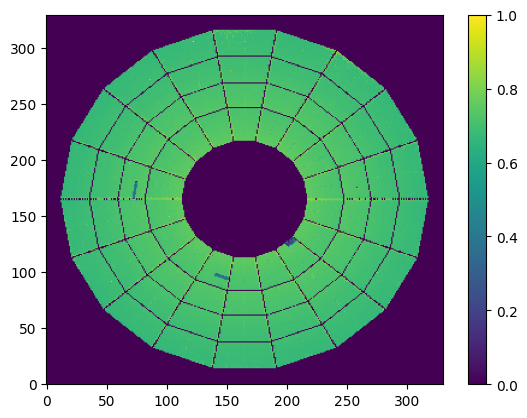

In [62]:
import numpy as np
max_log = np.log1p(tensor[0, :, :].detach().cpu().numpy()).max()

plt.imshow(
    np.log1p(tensor[0, :, :].detach().cpu().numpy())/np.log1p(tensor[0, :, :].detach().cpu().numpy().max()),
    cmap="viridis",
    origin="lower",
    aspect="auto",
)
plt.colorbar()
plt.show()

img_tensor = np.log1p(tensor[0, :, :].detach().cpu().numpy())/np.log1p(tensor[0, :, :].detach().cpu().numpy().max()),


In [47]:
torch.mean(tensor)

tensor(8289.2197)

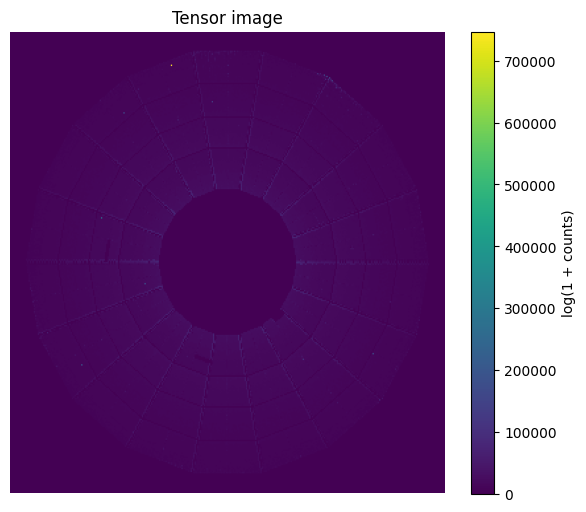

In [59]:
from root_tensor_utils import extract_histogram_info, root_to_th2, th2_to_tensor
import matplotlib.pyplot as plt

path = "/Users/zetasourpi/Desktop/GitRepoQC/AIQualityControl/data/tpc/train/TObject_1715229556734.root"

th2 = root_to_th2(path, hist_index=1)
tensor = th2_to_tensor(th2)

plt.figure(figsize=(7, 6))
plt.imshow(tensor[0,:,:], cmap="viridis", origin="lower", aspect="auto")
plt.colorbar(label="log(1 + counts)")
plt.title("Tensor image")
plt.axis("off")
plt.show()


root_tensor = np.log1p(tensor[0, :, :].detach().cpu().numpy())/np.log1p(tensor[0, :, :].detach().cpu().numpy().max())

# print(len(torch.nonzero(tensor)))
# print(tensor[0][14][139])
# tensor_from_root = tensor[0,:,:] # shape [330, 330]

# tensor_from_root.shape

In [61]:
root_tensor

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(330, 330), dtype=float32)

In [60]:
same = torch.allclose(img_tensor, root_tensor, rtol=1e-1, atol=1e-1)
print(same)

TypeError: allclose(): argument 'input' (position 1) must be Tensor, not tuple

# Check 

In [99]:

def normalize(tensor): 
    return np.log1p(tensor)/np.log1p(tensor).max()


In [100]:
import torch
import numpy as np
from PIL import Image

img_path = "/Users/zetasourpi/Desktop/GitRepoQC/AIQualityControl/data/tpc/train/rgb_images/TObject_1715229556734_0.png"

img = Image.open(img_path).convert("L")
arr = np.array(img)                 # shape [H, W, 3], values 0..255
tensor = torch.from_numpy(arr)      # still 0..255
img_tensor = tensor
img_tensor.shape


torch.Size([330, 330])

In [101]:
from root_tensor_utils import extract_histogram_info, root_to_th2, th2_to_tensor
import matplotlib.pyplot as plt

root_path = "/Users/zetasourpi/Desktop/GitRepoQC/AIQualityControl/data/tpc/train/TObject_1715229556734.root"

th2 = root_to_th2(root_path, hist_index=1)
root_tensor = th2_to_tensor(th2)[0,:,:]

In [102]:
img_tensor = normalize(img_tensor)
root_tensor = normalize(root_tensor)

/var/folders/39/byg2y3v51ts0gm8ycktqq0hw0000gn/T/ipykernel_61658/10403969.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.log1p(tensor)/np.log1p(tensor).max()


In [105]:
np.allclose(img_tensor, root_tensor, rtol=0.5, atol=0.5)

False

In [ ]:
from root_tensor_utils import extract_histogram_info, root_to_th2, th2_to_tensor, denormalize_tensor_log1p, tensor_to_th2, th2_to_root_object
import matplotlib.pyplot as plt

root_path = "/Users/zetasourpi/Desktop/GitRepoQC/AIQualityControl/data/tpc/train/TObject_1715229556734.root"
th2 = root_to_th2(root_path, hist_index=1)
root_tensor = th2_to_tensor(th2)[0,:,:]

info = extract_histogram_info(root_path, hist_index=0)
th2_back = tensor_to_th2(root_tensor, info)
root_canvas = th2_to_root_object(th2_back)

In [122]:
def denormalize(normalized_tensor, original_max):
    log_max = np.log1p(original_max)
    return np.expm1(normalized_tensor * log_max)


In [128]:
from root_tensor_utils import extract_histogram_info, root_to_th2, th2_to_tensor, denormalize_tensor_log1p, tensor_to_th2, th2_to_root_object
import matplotlib.pyplot as plt

root_path = "/Users/zetasourpi/Desktop/GitRepoQC/AIQualityControl/data/tpc/train/TObject_1715229556734.root"
th2 = root_to_th2(root_path, hist_index=0)
root_tensor = th2_to_tensor(th2)[0,:,:]

normalize_tensor = np.log1p(root_tensor)/np.log1p(root_tensor).max()
root_tensor = np.expm1(normalize_tensor * np.log1p(root_tensor).max())

info = extract_histogram_info(root_path, hist_index=0)
th2_back = tensor_to_th2(root_tensor, info)
root_canvas = th2_to_root_object(th2_back)

/var/folders/39/byg2y3v51ts0gm8ycktqq0hw0000gn/T/ipykernel_61658/3685337481.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  normalize_tensor = np.log1p(root_tensor)/np.log1p(root_tensor).max()
/var/folders/39/byg2y3v51ts0gm8ycktqq0hw0000gn/T/ipykernel_61658/3685337481.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  root_tensor = np.expm1(normalize_tensor * np.log1p(root_tensor).max())


In [129]:
info

HistogramTensorInfo(name='h_Aside_2D_N_Clusters_clone', title='N Clusters (A-Side)', pad_name='c_Sides_N_Clusters_1', tensor=tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]), x_bins=330, y_bins=330, x_min=-270.0, x_max=270.0, y_min=-270.0, y_max=270.0, value_min=0.0, value_max=62000.0, display_min=0.0, display_max=62000.0)

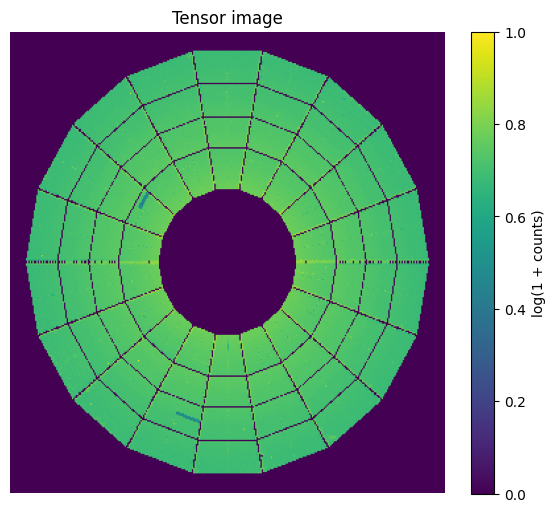

In [ ]:
th2 = root_to_th2(path, hist_index=0)
tensor = th2_to_tensor(th2)   # shape [1, 330, 330]
tensor = torch.squeeze(tensor) # shape [330, 330]

import matplotlib.pyplot as plt
import numpy as np
img = tensor.detach().cpu().numpy()

plt.figure(figsize=(7, 6))
plt.imshow(np.log1p(img)/np.log1p(img.max()), cmap="viridis", origin="lower", aspect="auto")
#plt.imshow(img, cmap="viridis", origin="lower", aspect="auto")
plt.colorbar(label="log(1 + counts)")
plt.title("Tensor image")
plt.axis("off")
plt.show()


In [ ]:
torch.max(tensor)

tensor(693493.)

In [ ]:
normalized = normalize_tensor_log1p(tensor, max_value=62000.0)

import matplotlib.pyplot as plt

plt.imshow(tensor[0], cmap='viridis')
plt.colorbar()
plt.title("Tensor image")
plt.axis("off")
plt.show()

Function wrapper of Root Object -> TH2 -> Tensor -> Normalized Tensor

In [ ]:
normalized_tensor, info = root_to_normalized_tensor(path, hist_index=0, max_value=62000.0)

In [ ]:
import torch 
equal = torch.all(normalized == normalized_tensor) 
equal 

tensor(True)

In [ ]:
normalized_tensor.shape

torch.Size([1, 330, 330])

In [ ]:
mask = (normalized_tensor[0] > 0)
mask.shape

torch.Size([330, 330])

In [ ]:
mask

tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]])

In [ ]:
masked_norm_tensor = normalized_tensor[:,mask]
masked_norm_tensor.shape

torch.Size([1, 60334])

In [ ]:
import torch
print(torch.nonzero(normalized_tensor), '\n',
      torch.nonzero(mask))


tensor([[  0,  14, 139],
        [  0,  14, 140],
        [  0,  14, 141],
        ...,
        [  0, 315, 188],
        [  0, 315, 189],
        [  0, 315, 190]]) 
 tensor([[ 14, 139],
        [ 14, 140],
        [ 14, 141],
        ...,
        [315, 188],
        [315, 189],
        [315, 190]])


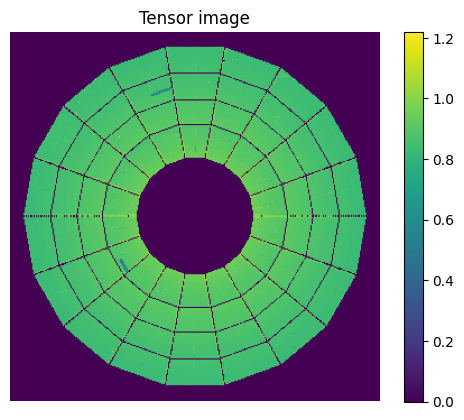

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(normalized_tensor[0], cmap='viridis')
plt.colorbar()
plt.title("Tensor image")
plt.axis("off")
plt.show()

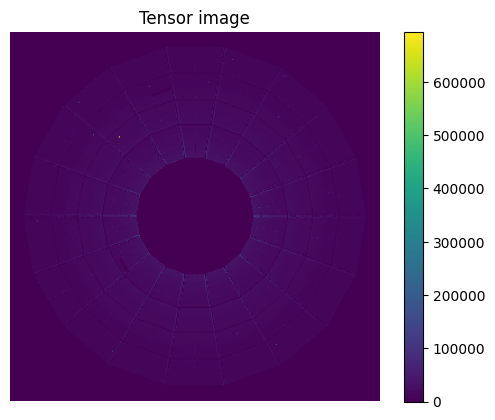

In [ ]:
from root_tensor_utils import denormalize_tensor_log1p

raw_tensor = denormalize_tensor_log1p(
    normalized_tensor,
    max_value=62000,
)

import matplotlib.pyplot as plt

plt.imshow(raw_tensor[0], cmap='viridis')
plt.colorbar()
plt.title("Tensor image")
plt.axis("off")
plt.show()

In [ ]:
mask

tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]])

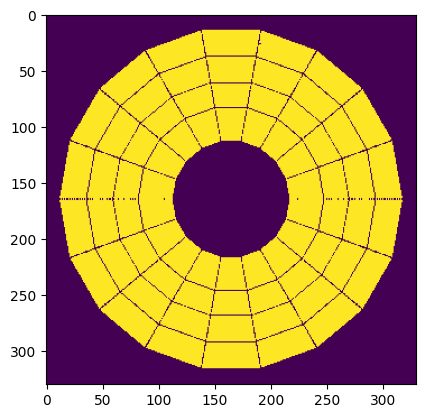

In [ ]:
plt.imshow(mask.cpu(), cmap='viridis')

# Save the mask in a root file

In [ ]:
#test
import torch
from root_tensor_utils import extract_histogram_info, tensor_to_th2, th2_to_root_object

root_path = "/Users/zetasourpi/Desktop/GitRepoQC/AIQualityControl/data/tpc/test/TObject_1721127357440.root"
hist_index = 1

# Get the original histogram metadata: binning, axis limits, title, etc.
info = extract_histogram_info(root_path, hist_index=hist_index)

# Your mask: [H, W] bool or 0/1
mask_2d = mask.cpu().float()

# tensor_to_th2 expects [1, H, W] or [H, W]
mask_th2 = tensor_to_th2(mask_2d.unsqueeze(0), info, hist_name="binary_mask")

# Save as ROOT canvas object
th2_to_root_object(
    mask_th2,
    canvas_name="ccdb_object",
    plot=False,
    save_path="mask.root",
)


IMPORTANT

total pixels = 330 × 330 = 108,900

non-zero pixels = ~60k

# De-normalize tensor -> Tensor -> TH2 -> Root Object

In [ ]:
import torch

def restore_masked_normalized_tensor(masked_tensor, mask, fill_value=0.0):
    if masked_tensor.ndim == 1:
        masked_tensor = masked_tensor.unsqueeze(0)

    full_tensor = torch.full(
        (masked_tensor.shape[0], *mask.shape),
        fill_value,
        dtype=masked_tensor.dtype,
        device=masked_tensor.device,
    )
    full_tensor[:, mask] = masked_tensor
    return full_tensor


In [ ]:
masked_norm_tensor.shape

torch.Size([1, 60334])

In [ ]:
input_norm_full = restore_masked_normalized_tensor(masked_norm_tensor, mask, fill_value=0.0)
print(input_norm_full.shape)
print(len(torch.nonzero(input_norm_full)))

torch.Size([1, 330, 330])
60334


In [ ]:
raw_tensor = denormalize_tensor_log1p(input_norm_full, max_value=62000.0)
th2_back = tensor_to_th2(raw_tensor, info)
root_canvas = th2_to_root_object(th2_back)

In [ ]:
canvas = normalized_tensor_to_root_object(
    normalized,
    info,
    max_value=62000.0,
    plot=True,
    save_path=None
)

In [ ]:
canvas

# Inspect if the corrsponding pngs at the test folder exist as root files and that we can read them properly

In [ ]:
from pathlib import Path
import re
import shutil

categories_folders_pngs = Path("/Users/zetasourpi/Desktop/GitRepoQC/AIQualityControl/data/tpc/test/rgb_images/categories_with_handpicked_training_samples")
test_folder = Path("/Users/zetasourpi/Desktop/GitRepoQC/AIQualityControl/data/tpc/test")
train_folder = Path("/Users/zetasourpi/Desktop/GitRepoQC/AIQualityControl/data/tpc/train")

for subdir in categories_folders_pngs.iterdir():
    if not subdir.is_dir():
        continue

    destination_dir = test_folder / "root_objects" / "categ" / subdir.name
    destination_dir.mkdir(parents=True, exist_ok=True)

    root_files_to_retrieve = []

    for image in subdir.iterdir():
        if image.suffix.lower() != ".png":
            continue
        root_name = re.sub(r"_[01]$", "", image.stem) + ".root"
        root_files_to_retrieve.append(root_name)

    for root_file in root_files_to_retrieve:
        train_src = train_folder / root_file
        test_src = test_folder / root_file
        dst = destination_dir / root_file

        if train_src.exists():
            shutil.copy2(train_src, dst)
        elif test_src.exists():
            shutil.copy2(test_src, dst)
        else:
            print(f"Missing: {root_file}")

In [ ]:
from pathlib import Path
import re
import shutil

rgb_images = Path("/Users/zetasourpi/Desktop/GitRepoQC/AIQualityControl/data/tpc/train/rgb_images")
train_folder = Path("/Users/zetasourpi/Desktop/GitRepoQC/AIQualityControl/data/tpc/train")

destination_dir = train_folder / "root_objects"
destination_dir.mkdir(parents=True, exist_ok=True)

seen = set()

for image in rgb_images.iterdir():
    if image.is_dir() or image.suffix.lower() != ".png":
        continue

    root_name = re.sub(r"_[01]$", "", image.stem) + ".root"
    if root_name in seen:
        continue
    seen.add(root_name)

    train_src = train_folder / root_name
    dst = destination_dir / root_name

    if train_src.exists():
        shutil.copy2(train_src, dst)
    else:
        print(f"Missing: {root_name}")

In [ ]:
# 1. ROOT -> normalized full tensor
tensor_norm, metadata = root_to_normalized_tensor(path, hist_index=hist_index, max_value=max_value)
# tensor_norm: [1, H, W]

# 2. Apply mask -> model input
tensor_masked = tensor_norm[:, mask]
# tensor_masked: [1, N_kept]

# 3. Model output
pred_masked = model(tensor_masked)
# pred_masked: [1, N_kept]

# 4. Go back to normalized full tensor
pred_norm_full = restore_masked_normalized_tensor(pred_masked, mask, fill_value=0.0)
# pred_norm_full: [1, H, W]


In [ ]:
import torch

def restore_masked_normalized_tensor(masked_tensor, mask, fill_value=0.0):
    if masked_tensor.ndim == 1:
        masked_tensor = masked_tensor.unsqueeze(0)

    full_tensor = torch.full(
        (masked_tensor.shape[0], *mask.shape),
        fill_value,
        dtype=masked_tensor.dtype,
        device=masked_tensor.device,
    )
    full_tensor[:, mask] = masked_tensor
    return full_tensor
